In [2]:
import pandas as pd

In [3]:
dataset = pd.read_csv("../datasets/50_Startups.csv")
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [21]:
dataset = pd.get_dummies(dataset, drop_first = True, dtype=int)

In [22]:
ind_var = dataset.drop("Profit", axis = 1)
dep_var = dataset["Profit"]

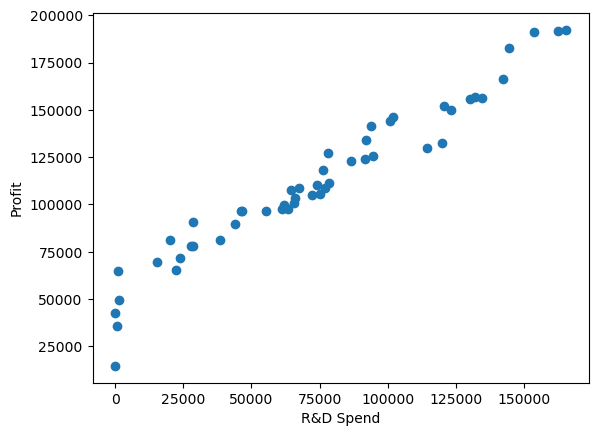

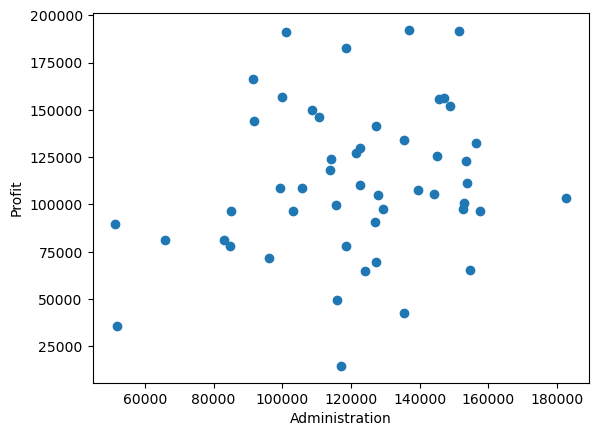

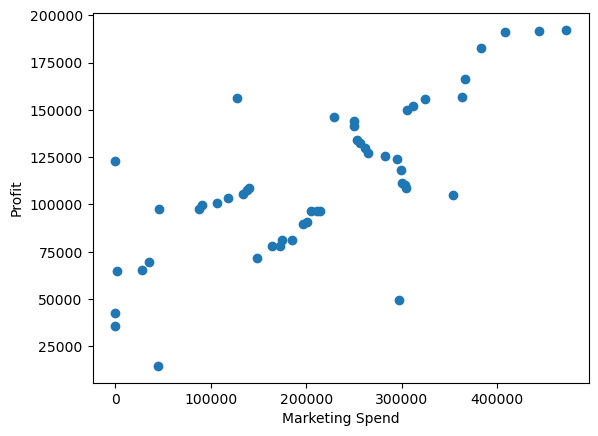

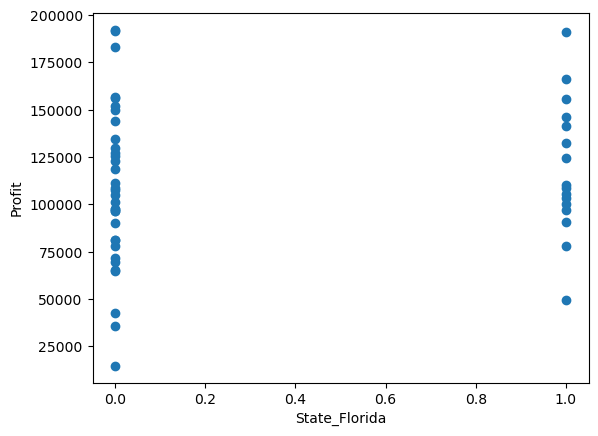

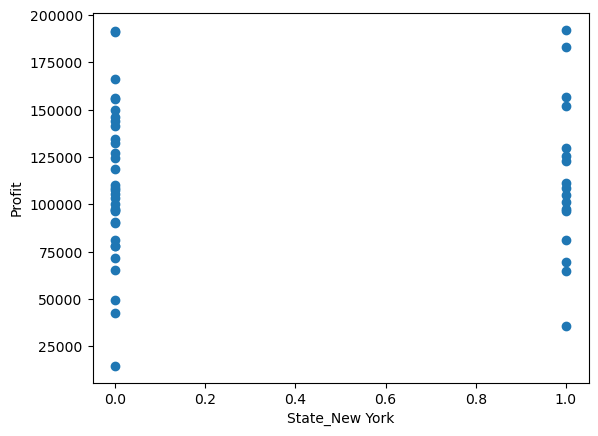

In [23]:
import matplotlib.pyplot as plt 

for col in ind_var:
    plt.scatter(dataset[col], dataset["Profit"])
    plt.xlabel(col)
    plt.ylabel("Profit")
    plt.show()

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(ind_var, dep_var, test_size=0.3, random_state=0)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [60]:
from sklearn.svm import SVR

model = SVR(kernel= 'linear', C=5000, gamma= 3)
model = model.fit(x_train, y_train)
y_pred = model.predict(x_test)
model.score(x_test, y_test)


0.9003762428272556

In [62]:
new_data = pd.DataFrame({
    "R&D Spend": [100000],
    "Administration": [50000],
    "Marketing Spend": [200000],
    "State_Florida": [1],
    "State_New York": [0]
})

new_data_scaled = scaler.transform(new_data)
newModel = model

newModel.predict(new_data_scaled)

array([118694.03268061])